# Критерий Колмогорова-Смирнова

Статья: https://github.com/avito-tech/applied_statistics/blob/main/Kolmogorov-Smirnov.ipynb

В критерии Колмогорова мы проверяли, что наше распределение равно какому-то $F$

Здесь у нас есть две выборки, и мы хотим проверить, что они из одного распределения. При этом неважно, какого именно 

$H_0: F_X = F_Y$    
$H_1: F_X \neq F_Y$

Статистика: 
$$\sqrt{\frac{nm}{n + m}} D_{nm} \xrightarrow{p} \phi$$

$$D_{nm} = \sup_{x \in \mathbb{R}} |\widehat{F}_{X_n}(x) - \widehat{F}_{Y_m}(x)|$$

**Важно, чтобы значения в каждой выборке были iid, и сами выборки были независимы**

Для зависимых выборок мы существенно теряем в мощности критерия по сравнению с независимыми. При этом мощность все равно стремится к 1 с увеличением выборки. Критерий все равно валиден, и может помочь обнаружить эффект.

Если вам встретится задача с зависимостью, можно попробовать провести AA-тест, и посмотреть, наcколько $Type I$ будет близок к $alpha$. Если $Type I$ сильно занижен, лучше применить другой критерий.

In [2]:
import numpy as np 
import pandas as pd
from scipy import stats

import math

import matplotlib.pyplot as plt
import seaborn as sns
import random

from tqdm import tqdm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.proportion import proportion_confint

from collections import namedtuple

plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 21
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [3]:
# Проверяем, что критерий работает 

# Оказывается, что он занижает type I при небольших n 

monteCarloResults = namedtuple('MonteCarloResults', ['type_one', 'ci_left', 'ci_right'])

def run_monte_carlo_aa(n, m, dist_x, dist_y, n_iter, alpha):
    count = 0
    for _ in range(n_iter):
        control = dist_x.rvs(n)
        test = dist_y.rvs(m)

        pvalue = stats.kstest(control, test).pvalue

        count += (pvalue <= alpha)

    type_one = count / n_iter
    ci_left, ci_right = proportion_confint(count=count, nobs=n_iter, alpha=0.05, method='wilson')

    return monteCarloResults(**{'type_one' : type_one, 'ci_left': ci_left, 'ci_right': ci_right})

(positive_rate, 
 confint_left_bound, 
 confint_right_bound) = run_monte_carlo_aa(n = 20, m = 20,
                                                   alpha = 0.05,
                                                   n_iter = 20000,
                                                   dist_x = stats.gamma(5, 110),
                                                   dist_y = stats.gamma(5, 110))

print('FPR: ', positive_rate)
print('FPR confint: ', (confint_left_bound, confint_right_bound))

FPR:  0.03275
FPR confint:  (0.030371680745774544, 0.03530777694865523)


In [4]:
# Посмотрим, начиная с какого n уровень значимости будет alpha

TPR_list = []

numpy_ceil = np.vectorize(math.ceil)

# перебираем размер выборки с логарифмическим шагом
for i in tqdm(numpy_ceil(np.geomspace(10, 3000, 10))):  
    mmk_res = run_monte_carlo_aa(n = i, m = i, 
                                         alpha = 0.05,
                                         n_iter = 10000,
                                         dist_x = stats.gamma(1, 2),
                                         dist_y = stats.gamma(1, 2))
    TPR_list.append([i, mmk_res])

plt.show()

100%|██████████| 10/10 [00:19<00:00,  1.99s/it]


(0.0, 0.052445163510315015)

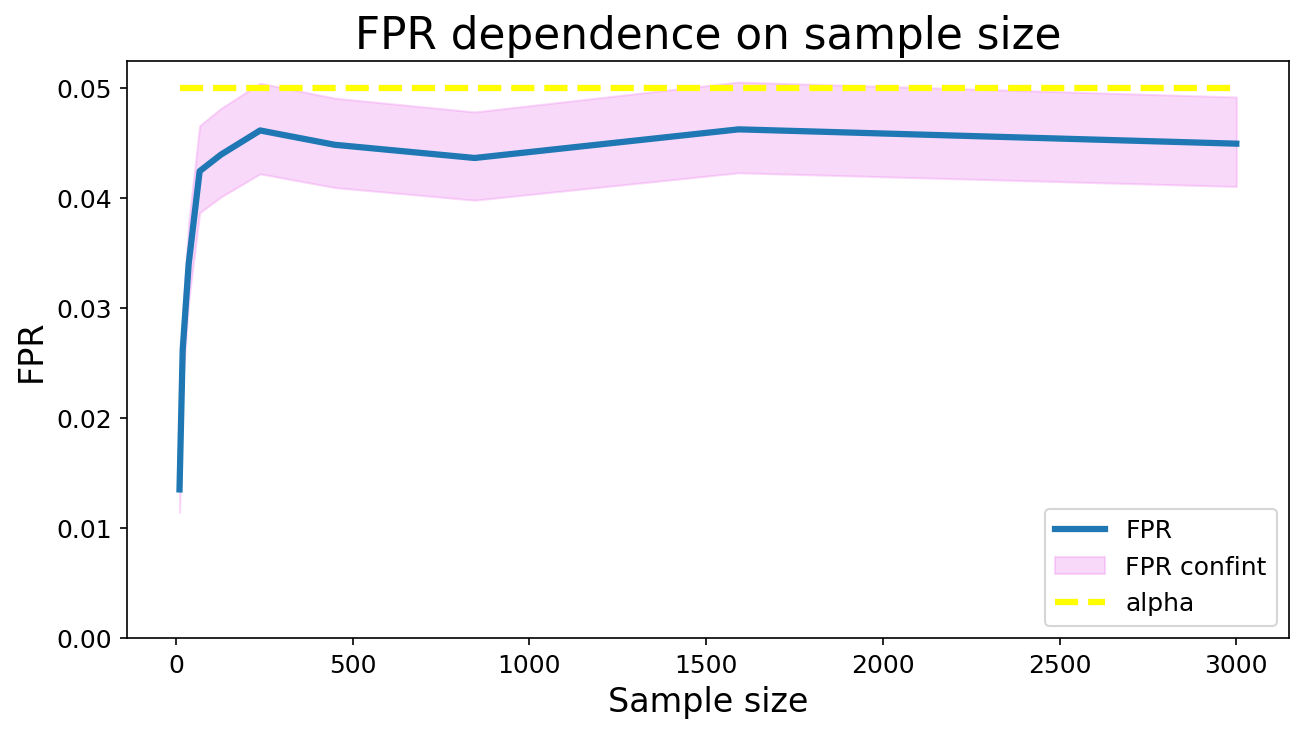

In [5]:
plt.figure(figsize=(10, 5))

plt.plot([elem[0] for elem in TPR_list], 
            [elem[1].type_one for elem in TPR_list], linewidth=3.0, label='FPR')
plt.fill_between([elem[0] for elem in TPR_list], 
                    [elem[1].ci_left for elem in TPR_list], 
                    [elem[1].ci_right for elem in TPR_list], 
                    color = 'violet', alpha = 0.3, label='FPR confint')
plt.plot([elem[0] for elem in TPR_list], np.array([0.05]*len(TPR_list)),
            color = 'yellow', linestyle = 'dashed', 
            linewidth=3.0, label='alpha')

plt.legend()
plt.title("FPR dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("FPR")
plt.ylim(bottom=0)

In [6]:
# Теперь сделаем AB Монте-Карло и посмотрим, как при увеличении n меняется мощность

# Увидим, что она увеличивается

TPR_list = []

numpy_ceil = np.vectorize(math.ceil)

# перебираем размер выборки с логарифмическим шагом
for i in tqdm(numpy_ceil(np.geomspace(10, 3000, 10))):  
    mmk_res = run_monte_carlo_aa(n = i, m = i, 
                                         alpha = 0.05,
                                         n_iter = 10000,
                                         dist_x = stats.gamma(1, 2),
                                         dist_y = stats.gamma(1.1, 2)) # меняем Y
    TPR_list.append([i, mmk_res])

plt.show()

100%|██████████| 10/10 [00:20<00:00,  2.09s/it]


(0.0, 1.0329990396252025)

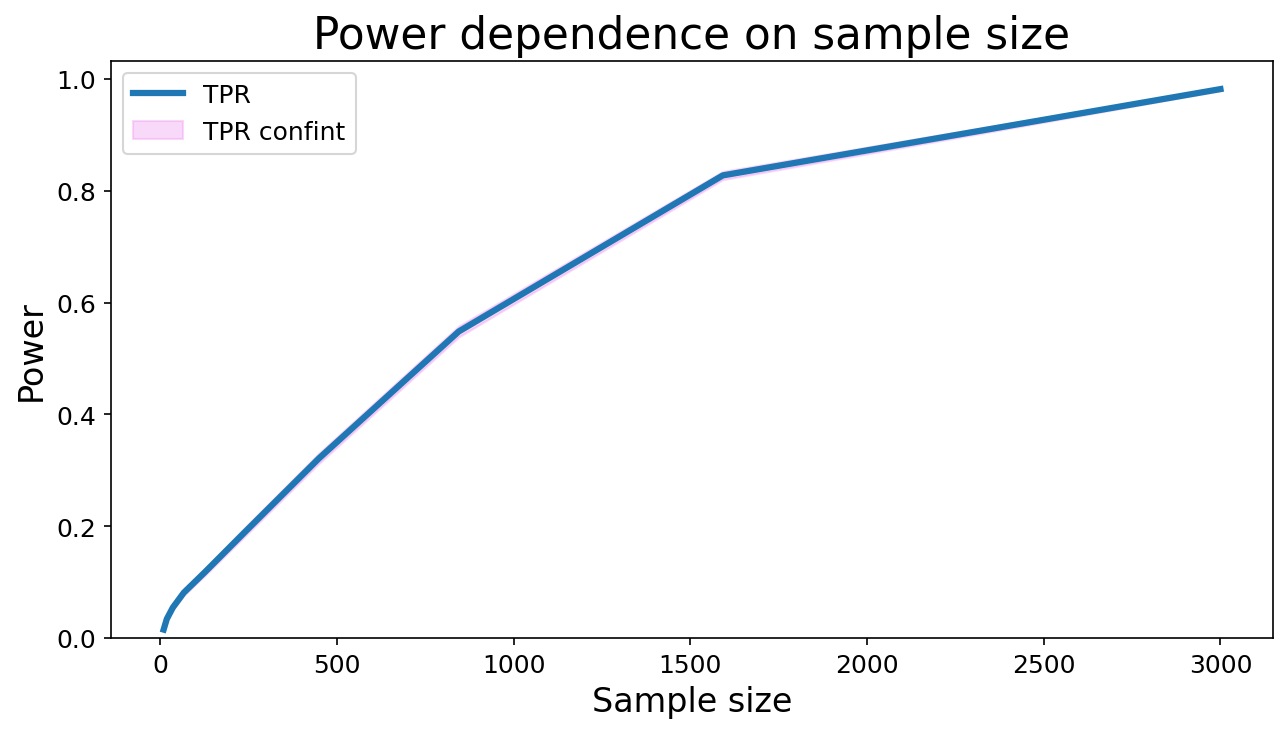

In [7]:
plt.figure(figsize=(10, 5))

plt.plot([elem[0] for elem in TPR_list], 
            [elem[1].type_one for elem in TPR_list], linewidth=3.0, label='TPR')
plt.fill_between([elem[0] for elem in TPR_list], 
                    [elem[1].ci_left for elem in TPR_list], 
                    [elem[1].ci_right for elem in TPR_list], 
                    color = 'violet', alpha = 0.3, label='TPR confint')

plt.legend()
plt.title("Power dependence on sample size")
plt.xlabel("Sample size")
plt.ylabel("Power")
plt.ylim(bottom=0)